# 01. Dataset Preparation and Descriptive Statistics / 'Contacts (Done).xlsx'

**How to use this notebook:**
- make a copy for each dataset: `01_data_prepare_deals.ipynb`, `01_data_prepare_calls.ipynb`, etc.
- fill in the config cell in each copy and go through all the steps
- write insights and decisions directly into the markdown cells

---
Tasks:   
`Data cleaning and preparation:`
1. Remove duplicates and irrelevant columns.
2. Handle missing values appropriately.
3. Convert data types for columns such as dates and numeric
values.

`Descriptive statistics:`
1. Calculate summary statistics (mean, median, mode,
range) for numeric fields.
2. Analyze categorical fields such as quality, stage, source, and
product.

---
## 1. Imports & Setup

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

import helpers as h

In [2]:
# Visualization settings
sns.set_style('whitegrid')
sns.set_palette('deep')

# Pandas settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Paths (notebook lives in notebooks/, data lives in data/)
PROJECT_ROOT = Path().resolve().parent
RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
BACKUP       = PROJECT_ROOT / 'data' / 'processed' / 'backup'
IMAGES       = PROJECT_ROOT / 'images'

# Create the backup folder if it doesn't exist yet
BACKUP.mkdir(parents=True, exist_ok=True)

---
## 2. Dataset Configuration for 'Contacts (Done).xlsx'

Fill in `name` and `filename` **before running** the rest of the cells.

In [3]:
# ── DATASET CONFIG ──────────────────────────────────────────────────────────
# Fill in name and filename - the rest comes after preliminary analysis

dataset_config = {

    # Short dataset name (Latin letters, no spaces)
    # Used as the file name when saving the config and backups
    # Examples: 'deals', 'contacts', 'calls', 'spend'
    'name':       'contacts',

    # Source file name in the data/raw/ folder
    'filename':   'Contacts (Done).xlsx',
    'config_pkl': 'config_contacts.pkl',
    'data_pkl':   'contacts_cleaned.pkl'
}

print(f"Dataset: {dataset_config['name']}")
print(f"File:    {dataset_config['filename']}")

Dataset: contacts
File:    Contacts (Done).xlsx


---
## 3. Loading Data

In [4]:
# Load the dataset by filename from the config
filepath = RAW / dataset_config['filename']

# Determine format from the file extension
if filepath.suffix == '.xlsx':
    df = pd.read_excel(filepath, dtype={'Id': str})
else:
    raise ValueError(f"Unsupported file format: {filepath.suffix}")

print(f"Loaded: {dataset_config['filename']}")
df_size_prev = (f"Original dataset size:   {df.shape[0]:_} rows × {df.shape[1]} columns")
print(df_size_prev)

Loaded: Contacts (Done).xlsx
Original dataset size:   18_548 rows × 4 columns


---
## 4. Preliminary Analysis

Take a first look at the data - what's actually in there.  
After this section, fill in the column types in Section 5.

In [5]:
# First rows
df.head()

,Id,Contact Owner Name,Created Time,Modified Time
0,5805028000000645014,Rachel White,27.06.2023 11:28,22.12.2023 13:34
1,5805028000000872003,Charlie Davis,03.07.2023 11:31,21.05.2024 10:23
2,5805028000000889001,Bob Brown,02.07.2023 22:37,21.12.2023 13:17
3,5805028000000907006,Bob Brown,03.07.2023 05:44,29.12.2023 15:20
4,5805028000000939010,Nina Scott,04.07.2023 10:11,16.04.2024 16:14


In [6]:
# Last rows
df.tail()

,Id,Contact Owner Name,Created Time,Modified Time
18543,5805028000056889209,Ulysses Adams,21.06.2024 12:11,21.06.2024 14:11
18544,5805028000056889351,Eva Kent,21.06.2024 13:32,21.06.2024 15:32
18545,5805028000056892018,Eva Kent,21.06.2024 10:21,21.06.2024 12:21
18546,5805028000056892055,Yara Edwards,21.06.2024 10:22,21.06.2024 12:23
18547,5805028000056907001,Ben Hall,21.06.2024 10:56,21.06.2024 12:56


### Cleaning Up Dataset Field Names

In [7]:
# Rename columns: strip whitespace and parentheses, convert to snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print("Columns after renaming:")
print(df.columns.tolist())

Columns after renaming:
['id', 'contact_owner_name', 'created_time', 'modified_time']


In [8]:
# Rename specific columns
df.rename(columns={'id': 'contact_id'}, inplace=True)
print("\nFirst rows of the DataFrame after renaming the field:")
df.head(3)


First rows of the DataFrame after renaming the field:


,contact_id,contact_owner_name,created_time,modified_time
0,5805028000000645014,Rachel White,27.06.2023 11:28,22.12.2023 13:34
1,5805028000000872003,Charlie Davis,03.07.2023 11:31,21.05.2024 10:23
2,5805028000000889001,Bob Brown,02.07.2023 22:37,21.12.2023 13:17


### Dataset Description

|Column name  | Description |   
|------------------|----------|  
| **contact_id**: | Contact ID|   
| **contact_owner_name**: | Sales manager handling this customer|   
| **created_time**: | Contact creation time|   
| **modified_time**: | Last modification time of the contact's data|

In [9]:
# Size and column dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   contact_id          18548 non-null  object
 1   contact_owner_name  18548 non-null  object
 2   created_time        18548 non-null  object
 3   modified_time       18548 non-null  object
dtypes: object(4)
memory usage: 579.8+ KB


In [10]:
df.describe(include='all')

,contact_id,contact_owner_name,created_time,modified_time
count,18548,18548,18548,18548
unique,18548,28,17921,16580
top,5805028000000645014,Charlie Davis,10.06.2024 09:00,13.06.2024 17:08
freq,1,2018,13,25


In [11]:
# Summary table for numeric columns 
h.descr_df(df)

No columns of type number found in the dataset


In [12]:
# Summary table for all categorical columns 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,contact_id,object,18548,0,18548,5805028000000645014,5805028000000872003,5805028000000889001
1,contact_owner_name,object,18548,0,28,Rachel White,Charlie Davis,Bob Brown
2,created_time,object,18548,0,17921,27.06.2023 11:28,03.07.2023 11:31,02.07.2023 22:37
3,modified_time,object,18548,0,16580,22.12.2023 13:34,21.05.2024 10:23,21.12.2023 13:17


In [13]:
# Missing values - first look
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df = missing_df.query('missing > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("No missing values")
else:
    display(missing_df)

No missing values


In [14]:
# Full duplicate rows - first look
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")

Duplicate rows: 0


**Dataset description:**   

Our 'Contacts' dataset has 18_548 observations and 4 variables.  
No missing values.  
'contact_id' has the int64 dtype

**Insights:** 
1) Ran an initial visual review of the dataset.  
2) Renamed columns (to snake_case, no parentheses or spaces).
3) Renamed id -> contact_id.  
4) created_time, modified_time - time fields, but stored as object dtype. Need to convert to Datetime. May also need to split into Date and Time.

---
## 5. Refining the Config: Column Types

Fill in the lists based on the preliminary analysis above.  
After filling them in, run the cell - the config will be saved.

In [15]:
num_cols = list(df.select_dtypes(include='number').columns)
print(num_cols)

[]


In [16]:
cat_cols = list(df.select_dtypes(include='object').columns)
print(cat_cols)

['contact_id', 'contact_owner_name', 'created_time', 'modified_time']


In [17]:
bool_cols = list(df.select_dtypes(include='bool').columns)
print(bool_cols)

[]


In [18]:
date_cols = list(df.select_dtypes(include='datetime').columns)
print(date_cols)

[]


In [19]:
# Fill in the lists based on Section 4's results ONCE, then run the code and comment it out
# If a column was already loaded from a saved config, it's fine to leave as-is

dataset_config['num_cols'] = [
    # Numeric: sla, initial_amount_paid, offer_total_amount, ...
    # '',
    *num_cols,
]

dataset_config['cat_cols'] = [
    # Categorical: stage, source, product, quality, ...
     'contact_owner_name' 
     # *cat_cols,
]

dataset_config['bool_cols'] = [
    # Boolean (True/False or 0/1): e.g. scheduled_in_crm
    # '',
    *bool_cols
]

dataset_config['date_cols'] = [
    # Dates: created_time, closing_date, ...
    'created_time', 'modified_time',
     *date_cols
]

dataset_config['drop_cols'] = [
    # Columns definitely not needed for analysis
    '',
]

# Remove empty placeholder strings from the lists
for key in ['num_cols', 'cat_cols', 'bool_cols', 'date_cols', 'drop_cols']:
    dataset_config[key] = [col for col in dataset_config[key] if col]

print("Config ready:")
print("=" * 50)
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Config ready:
  name: contacts
  filename: Contacts (Done).xlsx
  config_pkl: config_contacts.pkl
  data_pkl: contacts_cleaned.pkl
  num_cols: []
  cat_cols: ['contact_owner_name']
  bool_cols: []
  date_cols: ['created_time', 'modified_time']
  drop_cols: []


**Insights:** 

'created_time', 'modified_time' - time fields, but stored as object dtype.

### Saving the Config and Dataset to pkl

In [20]:
# Force id -> string
# to be sure the dtype doesn't shift (needed for merges)

id_cols = ['contact_id'] 

for col in id_cols:
    if col in df.columns:
        df[col] = df[col].astype('string')
        
# Save the CONFIG to pkl
sufix = 'config'
config_path = PROCESSED /  f"{sufix}_{dataset_config['name']}.pkl"

with open(config_path, "wb") as f:
    pickle.dump(dataset_config, f)
print(f"Config saved: {config_path.relative_to(PROJECT_ROOT)}")

# Save the DATASET to pkl
dataset_path = PROCESSED / f"{dataset_config['name']}_cleaned.pkl"    
df.to_pickle(dataset_path)

print(f"Dataset saved: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size: {df.shape[0]:_} × {df.shape[1]}")
print(f"{'─'*60}")
print(f"ID types: { {col: df[col].dtype for col in id_cols if col in df} }")

Config saved: data\processed\config_contacts.pkl
Dataset saved: data\processed\contacts_cleaned.pkl
Size: 18_548 × 4
────────────────────────────────────────────────────────────
ID types: {'contact_id': string[python]}


---
## 6. Converting Data Types

### Datetime Columns

In [21]:
# Convert dates
for col in dataset_config['date_cols']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True)
        print(f"  {col} -> datetime {df[col].dtype}")

  created_time -> datetime datetime64[ns]
  modified_time -> datetime datetime64[ns]


In [22]:
# Create a 'created_date' column containing only the date, format='%d.%m.%Y'
col = 'created_time'
df['created_date'] = pd.to_datetime(df[col].dt.date, format='%d.%m.%Y')
df['created_date'].dtype
print(f"Date range: {df['created_time'].min()} - {df['created_time'].max()}")

Date range: 2023-06-27 11:28:00 - 2024-06-21 15:30:00


### Numeric Columns

In [23]:
# Convert numeric columns
# errors='coerce' - non-numeric values become NaN
for col in dataset_config['num_cols']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"  {col} -> numeric {df[col].dtype}")

### Boolean Columns

In [24]:
# Convert boolean columns
for col in dataset_config['bool_cols']:
    if col in df.columns:
        # Skip if the column is already bool
        if df[col].dtype != bool:
            df[col] = df[col].astype(bool)
        print(f"  {col} -> bool {df[col].dtype}")

### Columns Definitely Not Needed for Analysis

In [25]:
# Drop unneeded columns
if dataset_config['drop_cols']:
    df = df.drop(columns=[c for c in dataset_config['drop_cols'] if c in df.columns])
    print(f"Dropped columns: {dataset_config['drop_cols']}")

### Final Column Types

In [26]:
print("Config updated:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Config updated:
  name: contacts
  filename: Contacts (Done).xlsx
  config_pkl: config_contacts.pkl
  data_pkl: contacts_cleaned.pkl
  num_cols: []
  cat_cols: ['contact_owner_name']
  bool_cols: []
  date_cols: ['created_time', 'modified_time']
  drop_cols: []


In [27]:
print(f"\nFinal column types:")
print(df.dtypes)


Final column types:
contact_id            string[python]
contact_owner_name            object
created_time          datetime64[ns]
modified_time         datetime64[ns]
created_date          datetime64[ns]
dtype: object


**Insights:** 

ID types: {'contact_id': string[python]}

---
## 7. Duplicates

In [28]:
# Full duplicate rows
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")

if n_dups > 0:
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

Duplicate rows: 0


**Decision on duplicates:** 

No duplicates found.

In [29]:
# Remove duplicates (uncomment if needed)
# df = df.drop_duplicates().reset_index(drop=True)
# print(f"After removing duplicates: {df.shape}")

---
## 8. Missing Values

In [30]:
# Final view of missing values after type conversion
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df = missing_df.query('missing > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("No missing values")
else:
    display(missing_df)

No missing values


In [31]:
# Handle missing values - fill in based on the decisions from the table above

# Example: fill numeric column with the median
# col = 'sla'
# df[col] = df[col].fillna(df[col].median())

# Example: fill categorical column with the mode
# col = 'payment_type'
# df[col] = df[col].fillna(df[col].mode()[0])

# Example: fill with a constant
# df['lost_reason'] = df['lost_reason'].fillna('not specified')

# Example: fill with the median within groups
# col = 'course_duration'
# df[col] = df[col].fillna(df.groupby(['product', 'education_type'])[col].transform('median'))
# If an entire group is empty, fall back to the global median
# df[col] = df[col].fillna(df[col].median())

# Check the result
print("Missing values after processing:")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("No missing values")
else:
    print(remaining)

Missing values after processing:
No missing values


---
## 9. Univariate Analysis - Numeric Variables

For each numeric variable:
- histogram + boxplot via `h.hist_box`
- outlier bounds via `h.iqr_outliers`

Record observations and outlier decisions in markdown cells below each chart.

In [32]:
for col in dataset_config['num_cols']:
    if col not in df.columns:
        print(f"Column {col} not found in the dataset, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Histogram + boxplot
    h.hist_box(col, df, title=col)
    print('Descriptive statistics:')
    display(h.descr_df(df[[col]], show=False).T)

    # Table with quantiles and outlier bounds
    print('Whisker bounds and outliers:')
    h.iqr_outliers(col, df)

**Observations and outlier decisions:**

Since this is **contact_id** - a unique contact identifier - there's nothing to process here (AUTO_INCREMENT PRIMARY KEY). No missing values.

In [33]:
# # If needed, uncomment and fill in to apply a log transform
# col = ...
# title = ...
# df[col + '_log1p'] = np.log1p(df[col])
# # Build histogram and boxplot for the log transform
# h.hist_box(col + '_log1p', df, 'log1p of ' + title)

In [34]:
# Handle outliers - fill in based on the decisions from the table above

# Example: remove right-side outliers
# col = 'sla'
# outliers = h.iqr_outliers(col, df, show=False)
# right_border = outliers.loc['Outlier bounds', 'Right']
# df = df[df[col] <= right_border].copy()
# print(f"After removing right-side outliers in {col}: {df.shape}")

# Example: remove left-side outliers
# col = 'initial_amount_paid'
# outliers = h.iqr_outliers(col, df, show=False)
# left_border = outliers.loc['Outlier bounds', 'Left']
# df = df[df[col] >= left_border].copy()

print(f"Dataset size after outlier handling: {df.shape}")

Dataset size after outlier handling: (18548, 5)


**Observations and decisions:**
If so, do it right here so we can move on to categorical variables with a clear conscience  
Make the change and write a short summary of what was done 

---
## 10. Univariate Analysis - Categorical Variables

For each categorical variable:
- frequency table with shares
- horizontal bar plot


────────────────────────────────────────────────────────────
  contact_owner_name  (28 unique values)
────────────────────────────────────────────────────────────


,contact_owner_name,count,%
0,Charlie Davis,2018,10.90
1,Ulysses Adams,1816,9.80
2,Julia Nelson,1769,9.50
3,Paula Underwood,1487,8.00
4,Quincy Vincent,1416,7.60
5,Nina Scott,1150,6.20
6,Ben Hall,1038,5.60
7,Victor Barnes,967,5.20
8,Cara Iverson,880,4.70
9,Rachel White,782,4.20


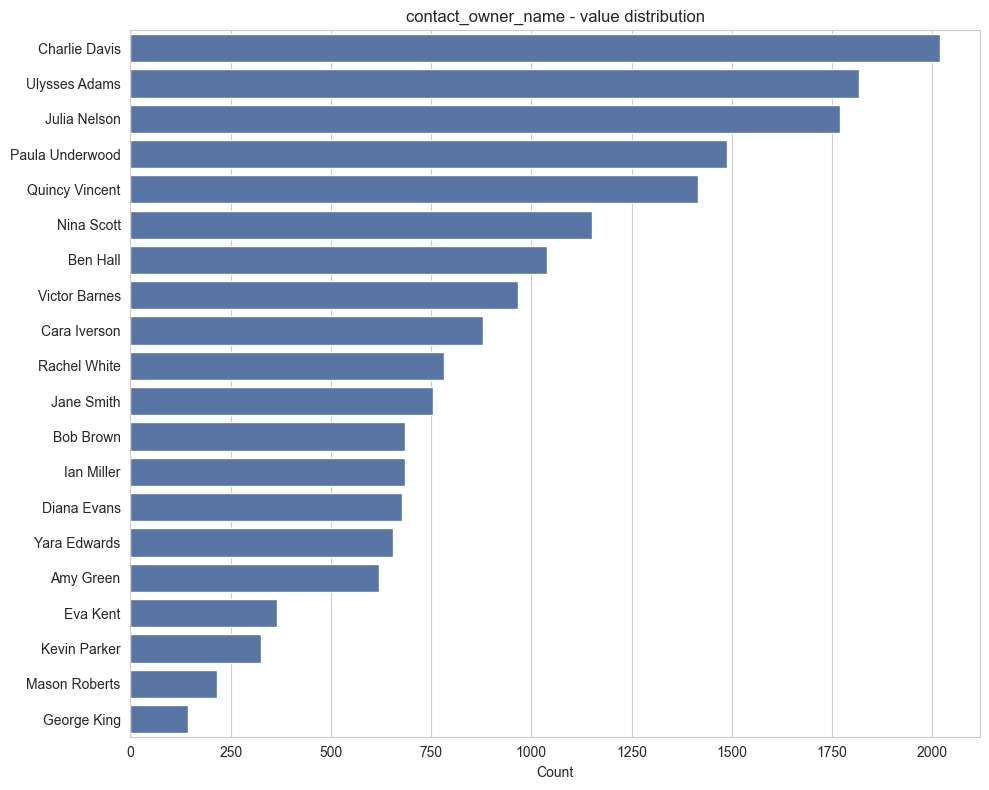

In [35]:
plt_to_save_png = ['contact_owner_name']  # Specify which variable's chart to save

for col in dataset_config['cat_cols']:
    if col not in df.columns:
        print(f"Column {col} not found, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}  ({df[col].nunique()} unique values)")
    print(f"{'─'*60}")

    # Frequency table
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq)

    # Bar plot (top 20 values if more)
    top_vals = freq.head(20)

    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', orient='h')
    plt.title(f"{col} - value distribution")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    if col in plt_to_save_png:
        plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_barplot.png",
                    dpi=150, bbox_inches='tight')
    plt.show()

In [36]:
# Load calls to look up the manager for a call by 'calls_id'
calls = pd.read_pickle(PROCESSED / 'calls_cleaned.pkl')

In [37]:
# One manual fix: 'False' -> 'George King'
# ['calls_id'] == '5805028000008772190']
# 'contact_owner_name' was False -> 'George King'
# Because from the calls dataset:
# Id' = '5805028000008771348'
# 'Call Start Time = 24.09.2023 11:43
# Call Owner Name = George King 
# CONTACTID = 5805028000008772190
#  this is the closest subsequent contact with the customer by date

df[df['contact_owner_name'] == False]

,contact_id,contact_owner_name,created_time,modified_time,created_date
2197,5805028000008772190,False,2023-09-24 09:01:00,2023-10-13 16:44:00,2023-09-24


In [38]:
# For the relevant 'contact_id', look up 'call_owner_name' - the manager on the call
calls[calls['contact_id'] == '5805028000008772190']

,calls_id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,dialled_number,outgoing_call_status,scheduled_in_crm,tag
9721,5805028000008771348,24.09.2023 11:43,George King,5805028000008772190,Outbound,1208.00,Attended Dialled,NaN,Completed,0.00,NaN


In [39]:
# Apply the fix and verify
df['contact_owner_name'] = df['contact_owner_name'].replace(False, 'George King')
df[df['contact_id'] == '5805028000008772190']

,contact_id,contact_owner_name,created_time,modified_time,created_date
2197,5805028000008772190,George King,2023-09-24 09:01:00,2023-10-13 16:44:00,2023-09-24


In [40]:
# Drop the earlier-loaded calls dataset
del calls
#  Check
try:
    print("'calls' still exists:", calls.shape())
except NameError:
    print("'calls' has been deleted")

'calls' has been deleted


**Observations and decisions:** 
One incorrect entry spotted in contact_owner_name = False. At this stage it's hard to identify the likely manager name. Left as-is for now.	

Working with the other dataset files, it became possible to determine this manager is George King, based on the sales funnel: **Contacts -> Calls -> Deals**.    
A single manual fix was applied.

`contact_owner_name`: 28 managers, top-5 = 46%   
Charlie Davis - (11%) >> the leader in contacts and completeness

---
## 11. Univariate Analysis - Date Columns

For each date column:
- range and basic statistics
- monthly distribution (time series)


────────────────────────────────────────────────────────────
  created_time
────────────────────────────────────────────────────────────
  Min:  2023-06-27 11:28:00
  Max: 2024-06-21 15:30:00
  Missing: 0


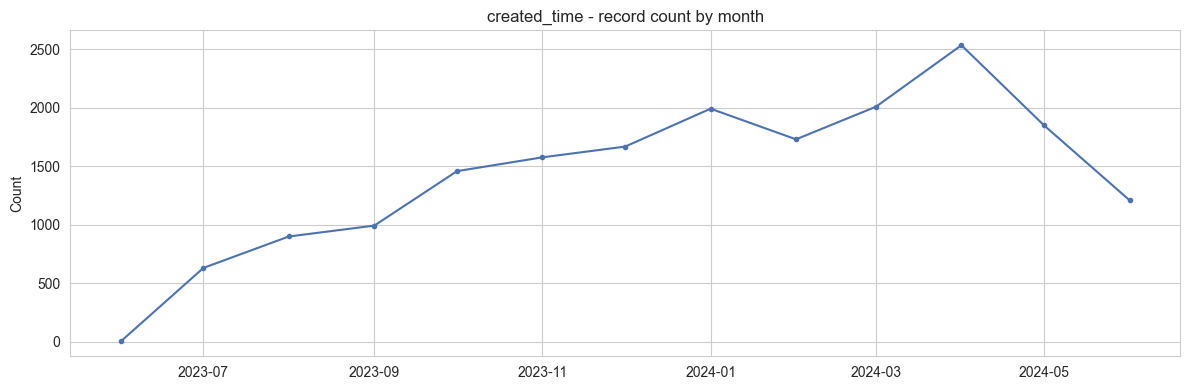


────────────────────────────────────────────────────────────
  modified_time
────────────────────────────────────────────────────────────
  Min:  2023-07-06 10:54:00
  Max: 2024-06-21 15:32:00
  Missing: 0


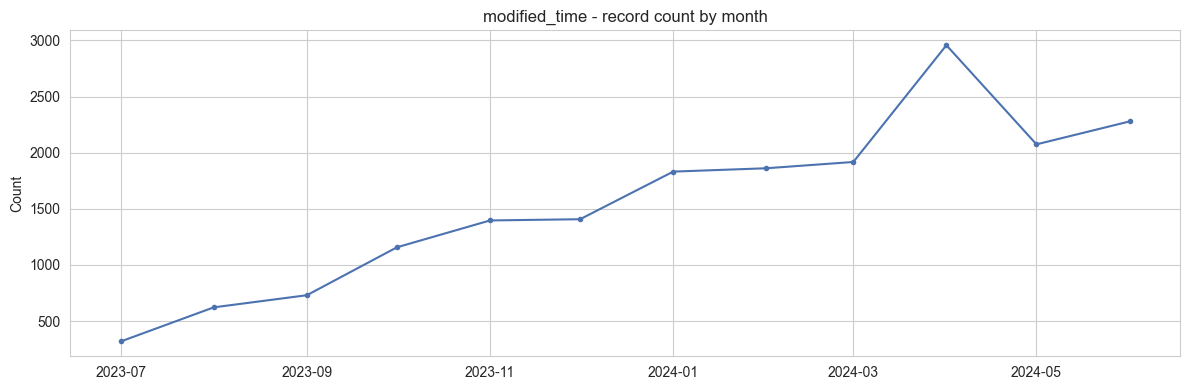

In [41]:
for col in dataset_config['date_cols']:
    if col not in df.columns:
        print(f"Column {col} not found, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Basic statistics
    print(f"  Min:  {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print(f"  Missing: {df[col].isnull().sum()}")

    # Monthly time series
    monthly = df.set_index(col).resample('MS').size()

    plt.figure(figsize=(12, 4))
    plt.plot(monthly.index, monthly.values, marker='o', markersize=3, linewidth=1.5)
    plt.title(f"{col} - record count by month")
    plt.ylabel("Count")
    plt.xlabel("")
    plt.tight_layout()
    # plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_timeseries.png",
    #             dpi=150, bbox_inches='tight')
    plt.show()

  created_time -> datetime datetime64[ns]
  modified_time -> datetime datetime64[ns]

#### Checking Call-Date Correctness

In [42]:
# Check that contact modification happens after contact creation
mask_time = df['modified_time'] < df['created_time']
mask_time.sum()

np.int64(0)

In [43]:
df.loc[mask_time, ['contact_id', 'contact_owner_name', 'created_time', 'modified_time']].head(5)

,contact_id,contact_owner_name,created_time,modified_time


**Date observations:**

| Range | created_time |  modified_time |      
|----------|--------------|----------------|    
| Min:  | 2023-06-27 11:28:00 | 2023-07-06 10:54:00 |      
| Max: | 2024-06-21 15:30:00 | 2024-06-21 15:32:00 |      
| Missing: | 0 |                   0 |       
 
  No missing values, modification dates are later than contact-creation dates.

---
## 12. Univariate Analysis - Boolean Variables

For boolean variables, look at the True / False ratio.

In [44]:
# for col in dataset_config['bool_cols']:
#     if col not in df.columns:
#         print(f"Column {col} not found, skipping")
#         continue

#     print(f"\n{'─'*60}")
#     print(f"  {col}")
#     print(f"{'─'*60}")

#     # Frequency table
#     freq = df[col].value_counts().reset_index()
#     freq.columns = [col, 'count']
#     freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
#     display(freq)

#     # Pie chart
#     plt.figure(figsize=(5, 5))
#     plt.pie(freq['count'], labels=freq[col].astype(str),
#             autopct='%1.1f%%', startangle=90)
#     plt.title(f"{col}")
#     plt.tight_layout()
#     # plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_pie.png",
#     #             dpi=150, bbox_inches='tight')
#     plt.show()

**Observations on boolean variables:**
There are no Boolean variables

---
## 13. Saving

Save the cleaned dataset to `data/processed/` as parquet.  
If a file with that name already exists, it's moved to `data/processed/backup/` with a timestamp.  
The config is updated in `data/processed/`.

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   contact_id          18548 non-null  string        
 1   contact_owner_name  18548 non-null  object        
 2   created_time        18548 non-null  datetime64[ns]
 3   modified_time       18548 non-null  datetime64[ns]
 4   created_date        18548 non-null  datetime64[ns]
dtypes: datetime64[ns](3), object(1), string(1)
memory usage: 724.7+ KB


In [46]:
# Save the updated dataset to xlsx
sufix = 'cleaned'

dataset_path = PROCESSED / f"{dataset_config['name']}_{sufix}.xlsx"

# If the file already exists - back it up before overwriting
if dataset_path.exists():
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    backup_path = BACKUP / f"{dataset_config['name']}_{sufix}_{timestamp}.xlsx"
    dataset_path.rename(backup_path)
    print(f"Previous file -> backed up as: {backup_path.name}")

# Save the cleaned dataset
df.to_excel(dataset_path, index=False)
print(f"Dataset saved:  {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size:            {df.shape[0]:_} rows × {df.shape[1]} columns")

Dataset saved:  data\processed\contacts_cleaned.xlsx
Size:            18_548 rows × 5 columns


In [47]:
# Save the updated CONFIG to pkl
sufix = 'config'
config_path = PROCESSED /  f"{sufix}_{dataset_config['name']}.pkl"

with open(config_path, "wb") as f:
    pickle.dump(dataset_config, f)
print(f"Config saved: {config_path.relative_to(PROJECT_ROOT)}")

# Save the updated DATASET to pkl
dataset_path = PROCESSED / f"{dataset_config['name']}_cleaned.pkl"    
df.to_pickle(dataset_path)

print(f"Dataset saved: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size: {df.shape[0]:_} × {df.shape[1]}")
print(f"{'─'*60}")
print(f"ID types: { {col: df[col].dtype for col in id_cols if col in df} }")

Config saved: data\processed\config_contacts.pkl
Dataset saved: data\processed\contacts_cleaned.pkl
Size: 18_548 × 5
────────────────────────────────────────────────────────────
ID types: {'contact_id': string[python]}


In [48]:
# Check that everything was saved
print("Contents of the processed/ folder:")
for f in sorted(PROCESSED.glob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")

print()
print("Contents of the backup/ folder:")
for f in sorted(BACKUP.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Contents of the processed/ folder:
  calls_cleaned.pkl  (9092.1 KB)
  config_calls.pkl  (0.3 KB)
  config_contacts.pkl  (0.3 KB)
  contacts_cleaned.pkl  (871.5 KB)
  contacts_cleaned.xlsx  (568.0 KB)

Contents of the backup/ folder:
  calls_cleaned_20261005_0841.xlsx  (4887.0 KB)
  contacts_cleaned_20261005_0843.xlsx  (568.0 KB)


---
## 14. Final Descriptive Statistics

In [49]:
# Can be loaded from PROCESSED to confirm everything was saved correctly 
# dataset_path

In [50]:
# Load the dataset by filename

dataset_path = PROCESSED / dataset_config['data_pkl']

# Load the cleaned dataset
df = pd.read_pickle(dataset_path)

# Print info about the load result
print(f"Loaded dataset: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Type: {type(df)} ")
print("=" * 80)
# Original dataset size:
print(df_size_prev)
df_size_old = (f"Dataset size after processing:   {df.shape[0]:_} rows × {df.shape[1]} columns")
print(df_size_old)

print("=" * 80)
df.info()
print("Checking the saved ID types:")
print(df[['contact_id']].dtypes)

Loaded dataset: data\processed\contacts_cleaned.pkl
Type: <class 'pandas.core.frame.DataFrame'> 
Original dataset size:   18_548 rows × 4 columns
Dataset size after processing:   18_548 rows × 5 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   contact_id          18548 non-null  string        
 1   contact_owner_name  18548 non-null  object        
 2   created_time        18548 non-null  datetime64[ns]
 3   modified_time       18548 non-null  datetime64[ns]
 4   created_date        18548 non-null  datetime64[ns]
dtypes: datetime64[ns](3), object(1), string(1)
memory usage: 724.7+ KB
Checking the saved ID types:
contact_id    string[python]
dtype: object


In [51]:
df.describe(include='all')

,contact_id,contact_owner_name,created_time,modified_time,created_date
count,18548,18548,18548,18548,18548
unique,18548,27,NaN,NaN,NaN
top,5805028000000645014,Charlie Davis,NaN,NaN,NaN
freq,1,2018,NaN,NaN,NaN
mean,NaN,NaN,2024-01-24 14:00:21.679965696,2024-02-15 07:41:24.814535168,2024-01-23 23:31:25.788225024
min,NaN,NaN,2023-06-27 11:28:00,2023-07-06 10:54:00,2023-06-27 00:00:00
25%,NaN,NaN,2023-11-15 16:40:45,2023-12-09 12:43:00,2023-11-15 00:00:00
50%,NaN,NaN,2024-02-01 18:30:00,2024-02-28 22:21:30,2024-02-01 00:00:00
75%,NaN,NaN,2024-04-12 16:37:15,2024-04-26 22:02:30,2024-04-12 00:00:00
max,NaN,NaN,2024-06-21 15:30:00,2024-06-21 15:32:00,2024-06-21 00:00:00


In [52]:
# Summary table for numeric columns 
h.descr_df(df)

No columns of type number found in the dataset


`Contacts` (18.5K unique):   
`Managers`: Charlie Davis 11%, top-5=46%, 75% filled in   
`Period`: created June'23-June'24, modified +3 wk,   75% of contacts generated before 2024-04-12   
`Every contact` is unique

In [53]:
# Summary table for object columns 
h.descr_df(df, include=['string'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,contact_id,string[python],18548,0,18548,5805028000000645014,5805028000000872003,5805028000000889001


In [54]:
# Summary table for object columns 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,contact_owner_name,object,18548,0,27,Rachel White,Charlie Davis,Bob Brown


In [55]:
# Frequency table
col = 'contact_owner_name'
freq = df[col].value_counts().reset_index()
freq.columns = [col, 'count']
freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
display(freq)

,contact_owner_name,count,%
0,Charlie Davis,2018,10.90
1,Ulysses Adams,1816,9.80
2,Julia Nelson,1769,9.50
3,Paula Underwood,1487,8.00
4,Quincy Vincent,1416,7.60
5,Nina Scott,1150,6.20
6,Ben Hall,1038,5.60
7,Victor Barnes,967,5.20
8,Cara Iverson,880,4.70
9,Rachel White,782,4.20


`Managers`: Charlie Davis 11%, top-5=46%, 27 managers total

In [56]:
# Summary table for bool columns 
h.descr_df(df, include=['bool'], show_stats=True, show_sample_rows=True)

No columns of type ['bool'] found in the dataset


In [57]:
# Summary table for datetime columns 
h.descr_df(df, include=['datetime'], show_stats=True, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,created_time,datetime64[ns],18548,0,17921,2023-06-27 11:28:00,2023-07-03 11:31:00,2023-07-02 22:37:00
1,modified_time,datetime64[ns],18548,0,16580,2023-12-22 13:34:00,2024-05-21 10:23:00,2023-12-21 13:17:00
2,created_date,datetime64[ns],18548,0,357,2023-06-27 00:00:00,2023-07-03 00:00:00,2023-07-02 00:00:00


In [58]:
# Date range
cols = ['created_time', 'created_date', 'modified_time']
for col in cols:
    print(f"{'─'*80}")    
    print(f" {col}:  Min:  {df[col].min()} - Max: {df[col].max()}")
    print(f"{'─'*80}")

────────────────────────────────────────────────────────────────────────────────
 created_time:  Min:  2023-06-27 11:28:00 - Max: 2024-06-21 15:30:00
────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────
 created_date:  Min:  2023-06-27 00:00:00 - Max: 2024-06-21 00:00:00
────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────
 modified_time:  Min:  2023-07-06 10:54:00 - Max: 2024-06-21 15:32:00
────────────────────────────────────────────────────────────────────────────────


**Dataset summary:**  

### Dataset Description

| Column name  | Description | dtypes |     
|------------------|----------|----|     
| **contact_id**: | Contact ID| string |     
| **contact_owner_name**: | Sales manager handling this customer| object |     
| **created_time**: | Contact creation time|  datetime64[ns] |     
| **created_date**: | Contact creation time / format='%d.%m.%Y'|  datetime64[ns] |    
| **modified_time**: | Last modification time of the contact's data|  datetime64[ns] |   


`Size:`   18548 rows × 4 columns  
`Missing:` 0   

Duplicate rows: 0  
No missing values   

**Column renaming:**   
Renamed columns (to snake_case, no parentheses or spaces).  
Renamed 'id'-> 'contact_id'

**Column type conversions:**   
Date observations:

| Range | created_time |  modified_time |      
|----------|--------------|----------------|    
| Min:  | 2023-06-27 11:28:00 | 2023-07-06 10:54:00 |      
| Max: | 2024-06-21 15:30:00 | 2024-06-21 15:32:00 |      
| Missing: | 0 |                   0 |       
 
  No missing values, modification dates are later than contact-creation dates. 